<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200"/>
</p></center>

<center><font size=10>AI Agents for Business Applications</center></font>
<center><font size=6>Additional Project Solution</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/1181467/pexels-photo-1181467.jpeg" width="640"/>
</p></center>

<center><font size=6> Technical Incident Investigation Assistant
</center></font>

# **Note**: This is a sample solution for the additional project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Problem Statement**

## Business Context

NovaTech Solutions is a mid-sized SaaS company providing cloud-based platforms for e-commerce and subscription businesses. Service reliability directly impacts revenue, so the IT operations team treats every incident seriously.

The company runs four production servers hosting microservices for authentication, payments, order management, notifications, user management, and reporting. These systems generate thousands of log entries per day across INFO, WARN, ERROR, and CRITICAL levels.

When an alert fires or a customer escalation comes in, an on-call engineer has to investigate. The investigation process today involves:

* Manually querying the log database to find relevant entries
* Looking up unfamiliar error messages, stack traces, or vendor-specific error codes online to understand what they mean
* Running ad-hoc analyses (filtering, aggregating, plotting) to spot patterns and outliers
* Tracing requests across services to understand blast radius
* Writing up findings in a structured report for the team

This process typically takes 30–90 minutes per investigation. Most of that time goes into mechanical work  running queries, switching between tools, reading documentation, formatting summaries rather than the actual reasoning the engineer brings to the problem.

The IT team wants an AI-powered assistant that handles the mechanical work and produces a starting-point investigation report in minutes, leaving the engineer to validate, refine, and act on the findings.

## Objective

Build a single-agent system that acts as an **investigation assistant** for an on-call engineer. Given a natural-language incident description, the agent should:

* **Plan** the investigation steps before acting
* **Query the log database** to gather evidence (logs, statistics, service dependencies)
* **Search the web** when it encounters error messages, stack traces, or vendor codes it doesn't recognize from its existing knowledge
* **Run Python analyses** on retrieved data to compute statistics, identify outliers, or trace requests across services
* **Synthesize findings** into a clear investigation report with the evidence chain that produced them

The system is explicitly an **assistant**, not an autonomous detector. A human engineer reviews the output and decides on remediation. The goal is to compress the mechanical parts of the investigation, not to replace human judgment about what to do next.

Concretely, the agent should:

* Adapt its tool sequence to what the incident actually requires (different incidents need different evidence)
* Use all three tool categories - SQL, web search, Python, when the problem warrants
* Surface its reasoning at each step so the engineer can follow and validate
* Produce a final report that includes the root cause hypothesis, supporting evidence, and recommended next actions

The deliverable is the agent itself, demonstrated on three investigation scenarios that exercise different tool combinations.

## Data Description


Synthetic server log data for NovaTech Solutions covering 2025-06-09 through 2025-06-15 is provided as a SQLite database with five tables.

**Database: `novatech_logs.db`**

1. **server_logs** - Raw log entries from all production servers
   - `log_id` (INTEGER) - Primary key
   - `timestamp` (DATETIME) - When the log was recorded
   - `server_id` (TEXT) - server_01, server_02, server_03, server_04
   - `log_level` (TEXT) - INFO, WARN, ERROR, CRITICAL
   - `service_name` (TEXT) - auth-service, payment-api, order-service, notification-service, user-service, reporting-service
   - `message` (TEXT) - Raw log message
   - `response_time_ms` (INTEGER) - Response time in milliseconds
   - `cpu_usage_percent` (FLOAT) - CPU usage at the time of the log
   - `memory_usage_percent` (FLOAT) - Memory usage at the time of the log
   - `request_id` (TEXT, nullable) - Correlation ID for tracing requests across services

2. **anomaly_thresholds** - Reference thresholds for metric-based investigation
   - `threshold_id` (INTEGER) - Primary key
   - `metric_name` (TEXT) - Name of the system metric being monitored
   - `warning_threshold` (FLOAT) - Value at which a warning should be triggered
   - `critical_threshold` (FLOAT) - Value at which a critical alert should be triggered
   - `consecutive_count` (INTEGER) - Number of consecutive breaches required to flag an anomaly

3. **known_error_patterns** - A small dictionary of common error keywords and their severity.

   - `pattern_id` (INTEGER) - Primary key
   - `pattern_keyword` (TEXT) - The specific keyword or string matching the error pattern
   - `severity` (TEXT) - Severity classification (e.g., Medium, High, Critical)
   - `description` (TEXT) - Human-readable explanation of the error pattern

4. **service_dependencies** - Static map of which services call which
   - `dependency_id` (INTEGER) - Primary key
   - `upstream_service` (TEXT) - The calling service initiating the request
   - `downstream_service` (TEXT) - The target service receiving the request
   - `dependency_type` (TEXT) - Communication type (e.g., synchronous, asynchronous)

5. **sqlite_sequence** - SQLite internal table
   - `name` (TEXT) - Name of the table utilizing an AUTOINCREMENT primary key
   - `seq` (INTEGER) - The current highest sequence value generated for that table

# **Installing and Importing Necessary Libraries and Dependencies**

In [ ]:
!pip install -q \
    langchain==0.3.27 \
    langchain-openai==0.3.35 \
    langgraph==0.6.11 \
    openai==2.32.0 \
    ddgs==9.14.1 \
    pandas==2.2.2 \
    numpy==2.0.2 \
    matplotlib==3.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 84.4 MB/s eta 0:00:00


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the install cell, you might see warnings regarding package dependencies. These warnings can usually be ignored — the notebook is tested with the versions pinned above.

In [ ]:
import os
import io
import json
import sqlite3
import contextlib
from ddgs import DDGS
from typing import TypedDict, Annotated, Sequence, Optional

import numpy as np
import pandas as pd

from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
)
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# **Data Loading and Model Initialization**

## Model Initialization

We first extract the required credentials from the `config.json` file.

In [ ]:
# Load the credentials JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                                             # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                  # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

In [ ]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

- Using one LLM for planning, tool execution, and reporting eliminates inter-agent communication overhead and state desynchronization risks.

- Setting `temperature=0` forces deterministic greedy decoding to guarantee highly repeatable execution traces across autonomous loops.

## Data Loading



Next, we load the SQLite database, print the tables present in it, and check the number of records in each table.

In [ ]:
DB_PATH = "novatech_logs.db"

con = sqlite3.connect(DB_PATH)
con.row_factory = sqlite3.Row  # nicer dict-like rows
cur = con.cursor()

# List tables (ignoring internal SQLite tables)
tables = cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name != 'sqlite_sequence' ORDER BY name").fetchall()
print("Tables:", [t["name"] for t in tables])

# Check row counts
for t in [t["name"] for t in tables]:
    c = cur.execute(f"SELECT COUNT(*) AS n FROM {t}").fetchone()["n"]
    print(f"{t:22s} {c}")

Tables: ['anomaly_thresholds', 'known_error_patterns', 'server_logs', 'service_dependencies']
anomaly_thresholds     3
known_error_patterns   12
server_logs            3195
service_dependencies   12


### Inspect and Preview Data

We will take a quick look at the log level distribution to ensure our data loaded correctly.

In [ ]:
# Log Level Distribution
print("=== LOG LEVEL DISTRIBUTION ===")
level_dist = cur.execute("SELECT log_level, COUNT(*) as count FROM server_logs GROUP BY log_level ORDER BY count DESC").fetchall()
for r in level_dist:
    print(f"  {r['log_level']:<10} : {r['count']:>5} entries")

# Preview Known Error Patterns
print("\n=== KNOWN ERROR PATTERNS ===")
for r in cur.execute("SELECT pattern_keyword, severity FROM known_error_patterns LIMIT 5").fetchall():
    print(f"  {r['pattern_keyword']:<32} {r['severity']}")

# Preview Service Dependencies
print("\n=== SERVICE DEPENDENCIES ===")
for r in cur.execute("SELECT upstream_service, downstream_service, dependency_type FROM service_dependencies LIMIT 5").fetchall():
    print(f"  {r['upstream_service']:<22} -> {r['downstream_service']:<22} ({r['dependency_type']})")

# Preview Sample Error/Critical Logs
print("\n=== SAMPLE ERROR / CRITICAL LOGS ===")
query = """
SELECT timestamp, server_id, log_level, service_name, SUBSTR(message, 1, 60) as msg
FROM server_logs
WHERE log_level IN ('ERROR', 'CRITICAL')
ORDER BY timestamp ASC LIMIT 5
"""
for r in cur.execute(query).fetchall():
    print(f"  {r['timestamp']} | {r['server_id']} | {r['log_level']:<8} | {r['service_name']:<22} | {r['msg']}...")

=== LOG LEVEL DISTRIBUTION ===
  INFO       :  2993 entries
  WARN       :   168 entries
  ERROR      :    25 entries
  CRITICAL   :     9 entries

=== KNOWN ERROR PATTERNS ===
  OutOfMemoryError                 Critical
  Connection refused               High
  Disk full                        Critical
  Segmentation fault               Critical
  Timeout exceeded                 High

=== SERVICE DEPENDENCIES ===
  payment-api            -> auth-service           (synchronous)
  order-service          -> auth-service           (synchronous)
  order-service          -> payment-api            (synchronous)
  order-service          -> notification-service   (asynchronous)
  notification-service   -> email-relay            (synchronous)

=== SAMPLE ERROR / CRITICAL LOGS ===
  2025-06-15 02:14:33 | server_01 | CRITICAL | auth-service           | OutOfMemoryError: Java heap space exceeded limit...
  2025-06-15 02:15:01 | server_01 | ERROR    | auth-service           | Authentication failed

We will also extract our anomaly thresholds into a string so we can easily inject them into our agent's prompts later.

In [ ]:
# Build a formatted string for injection into prompts later
threshold_rows = cur.execute("SELECT metric_name, warning_threshold, critical_threshold, consecutive_count FROM anomaly_thresholds").fetchall()
threshold_lines = "".join(
    f"  - {r['metric_name']}: Warning >= {r['warning_threshold']}, Critical >= {r['critical_threshold']} (for {r['consecutive_count']}+ consecutive logs)"
    for r in threshold_rows
)
threshold_lines

'  - response_time_ms: Warning >= 1500.0, Critical >= 3000.0 (for 3+ consecutive logs)  - cpu_usage_percent: Warning >= 75.0, Critical >= 90.0 (for 3+ consecutive logs)  - memory_usage_percent: Warning >= 80.0, Critical >= 95.0 (for 3+ consecutive logs)'

# **Defining Tools**

| Tool                       | What it helps the agent do                                                                                                                                   |
| -------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `query_logs`               | Retrieve raw records from `server_logs` using filters such as `server_id`, `service_name`, `log_level`, timeframe, `request_id`, or message content          |
| `get_log_stats`            | Generate aggregated counts from `server_logs` grouped by `server_id`, `service_name`, and/or `log_level`                                                     |
| `get_service_dependencies` | Retrieve `upstream_service`, `downstream_service`, and `dependency_type` relationships from `service_dependencies`                                           |
| `get_known_patterns`       | Retrieve known error signatures, severity levels, and descriptions from `known_error_patterns`                                                               |
| `web_search`               | Search for information about unfamiliar error messages, exception types, technologies, frameworks, or cloud service issues not covered by local data sources |
| `run_python_analysis`      | Execute custom Pandas/Numpy analysis on data returned by `query_logs` using the provided DataFrame `df` and raw record list `data`                           |


### Tool 1: Query Logs

> In this section, we will build a tool that filters the `server_logs` database by specific parameters like timeframes, server IDs, or error levels and returns the matching records as a clean JSON list.

In [ ]:
@tool
def query_logs(
    server_id: Optional[str] = None,
    service_name: Optional[str] = None,
    log_level: Optional[str] = "WARN,ERROR,CRITICAL",
    start_time: Optional[str] = None,
    end_time: Optional[str] = None,
    message_contains: Optional[str] = None,
    request_id: Optional[str] = None,
    limit: int = 100,
) -> str:
    """
    Retrieve raw log entries from the server_logs table using filters such as
    server_id, service_name, log_level, timestamp range, request_id, or
    message content.

    Use this tool when investigating a specific incident, error, service,
    request, or timeframe and you need the underlying log records.
    Returns matching rows from server_logs as JSON.
    """
    # Cap the limit to prevent massive payload issues
    limit = min(int(limit), 500)

    where = []
    params = []

    if server_id:
        where.append("server_id = ?")
        params.append(server_id)

    if service_name:
        where.append("service_name = ?")
        params.append(service_name)

    # Simple comma-separated string parsing
    if log_level:
        levels = [lvl.strip() for lvl in log_level.split(",") if lvl.strip()]
        placeholders = ",".join(["?"] * len(levels))
        where.append(f"log_level IN ({placeholders})")
        params.extend(levels)

    if start_time:
        where.append("timestamp >= ?")
        params.append(start_time)

    if end_time:
        where.append("timestamp <= ?")
        params.append(end_time)

    if message_contains:
        where.append("message LIKE ?")
        params.append(f"%{message_contains}%")

    if request_id:
        where.append("request_id = ?")
        params.append(request_id)

    where_clause = ("WHERE " + " AND ".join(where)) if where else ""

    sql = f"""
    SELECT log_id, timestamp, server_id, log_level, service_name,
           message, response_time_ms, cpu_usage_percent, memory_usage_percent, request_id
    FROM server_logs
    {where_clause}
    ORDER BY timestamp ASC
    LIMIT ?
    """
    params.append(limit)

    # Execute using standard sqlite3
    with sqlite3.connect(DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        rows = cursor.execute(sql, params).fetchall()

    # Convert to a simple list of dictionaries
    result = [dict(row) for row in rows]

    return json.dumps(result, indent=2)

### Tool 2: Get Log Statistics

> In this section, we will build a tool that aggregates log records from the `server_logs` database and returns counts grouped by fields such as server, service, or log level, with optional timeframe filters.
  

In [ ]:
@tool
def get_log_stats(
    group_by: str = "log_level",
    start_time: Optional[str] = None,
    end_time: Optional[str] = None,
) -> str:
    """
    Generate aggregated counts from the server_logs table grouped by
    server_id, service_name, and/or log_level, optionally within a
    specified timeframe.

    Use this tool to understand the overall distribution of log activity
    before inspecting individual log records. Returns grouped counts as JSON.
    """
    # Validate columns to prevent SQL injection
    allowed_columns = {"server_id", "service_name", "log_level"}
    group_columns = [col.strip() for col in group_by.split(",") if col.strip()]
    invalid_columns = [col for col in group_columns if col not in allowed_columns]

    if invalid_columns:
        return json.dumps({"error": f"Invalid group_by columns: {invalid_columns}"})

    where = []
    params = []

    if start_time:
        where.append("timestamp >= ?")
        params.append(start_time)

    if end_time:
        where.append("timestamp <= ?")
        params.append(end_time)

    where_clause = ("WHERE " + " AND ".join(where)) if where else ""
    columns_sql = ", ".join(group_columns)

    sql = f"""
    SELECT {columns_sql}, COUNT(*) AS count
    FROM server_logs
    {where_clause}
    GROUP BY {columns_sql}
    ORDER BY count DESC
    """

    # Execute using standard sqlite3
    with sqlite3.connect(DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        rows = cursor.execute(sql, params).fetchall()

    # Convert to a simple list of dictionaries
    result = [dict(row) for row in rows]

    return json.dumps(result, indent=2)

### Tool 3: Get Service Dependencies

> In this section, we will build a tool that retrieves service dependency relationships from the `service_dependencies` table, allowing us to inspect how microservices are connected and optionally filter the results for a specific service.


In [ ]:
@tool
def get_service_dependencies(service_name: Optional[str] = None) -> str:
    """
    Retrieve service relationships from the service_dependencies table,
    including upstream_service, downstream_service, and dependency_type.

    Use this tool to understand how services depend on each other and to
    assess whether an issue in one service could affect other services.
    Returns matching dependency relationships as JSON.
    """
    sql = "SELECT upstream_service, downstream_service, dependency_type FROM service_dependencies"
    params = []

    if service_name:
        sql += " WHERE upstream_service = ? OR downstream_service = ?"
        params.extend([service_name, service_name])

    # Execute using standard sqlite3
    with sqlite3.connect(DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        rows = cursor.execute(sql, params).fetchall()

    # Convert to a simple flat list of dictionaries
    result = [dict(row) for row in rows]

    return json.dumps(result, indent=2)

### Tool 4: Get Known Error Patterns

> In this section, we will build a tool that retrieves the known error pattern library from the `known_error_patterns` table, returning predefined error signatures along with their severity levels and descriptions.


In [ ]:
@tool
def get_known_patterns() -> str:
    """
    Retrieve known error signatures from the known_error_patterns table,
    including pattern_keyword, severity, and description.

    Use this tool when investigating an error message found in server_logs.
    Check this source before using web_search because it contains
    environment-specific knowledge about previously documented issues.
    Returns known error patterns as JSON.
    """
    sql = "SELECT pattern_keyword, severity, description FROM known_error_patterns ORDER BY severity"

    # Execute using standard sqlite3
    with sqlite3.connect(DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        rows = cursor.execute(sql).fetchall()

    # Convert to a simple flat list of dictionaries
    result = [dict(row) for row in rows]

    return json.dumps(result, indent=2)

### Tool 5: Web Search

> In this section, we introduce a critical capability for AI agent: interacting with the outside world. Up until now, our agent has only known what is stored in its local database or its pre-trained memory. But what happens when it encounters a brand-new error code, a specific cloud exception, or a framework issue it doesn't recognize?

To solve this, we give the agent a "tool" to browse the internet. Below is the code for a web_search tool.

> DuckDuckGo Search (DDGS): Instead of using a paid API like Google, this code uses a free Python library called ddgs (DuckDuckGo Search) to query the web. Unlike many other search APIs, it does not require any credentials or API keys to use. It's a great, lightweight way to fetch search engine results programmatically.

In [ ]:
@tool
def web_search(query: str, max_results: int = 5) -> str:
    """
    Search the web for information about unfamiliar error messages,
    exception types, technologies, frameworks, cloud services, or
    technical terms.

    Use this tool only when the required information cannot be found in
    server_logs, service_dependencies, or known_error_patterns.
    Returns relevant web search results as JSON.
    """
    max_results = min(int(max_results), 8)

    try:
        from ddgs import DDGS
    except ImportError:
        return json.dumps([{"error": "ddgs library not installed."}])

    try:
        with DDGS() as ddgs:
            raw_results = list(ddgs.text(query, max_results=max_results))
    except Exception as e:
        return json.dumps([{"error": f"Web search failed: {e}. Try a different query or proceed without it."}])

    formatted_results = [
        {
            "title": r.get("title", ""),
            "url": r.get("href", ""),
            "snippet": (r.get("body", "") or "")[:400]
        }
        for r in raw_results
    ]

    return json.dumps(formatted_results, indent=2)

### Tool 6: Run Python Analysis

> In this section, we will build a tool that takes a list of log records as input, loads them into a pandas DataFrame, executes custom Python analysis code against the data, and returns the resulting output.


In [ ]:
@tool
def run_python_analysis(data: list, code: str) -> str:
    """
    Execute custom Python analysis against a provided dataset.

    The input records are available as a Pandas DataFrame named `df`
    and as the original list named `data`.

    Use this tool when the task requires calculations, comparisons,
    aggregation, ranking, trend analysis, anomaly detection, statistical
    analysis, or other operations that are difficult to perform by manually
    inspecting records. Returns the printed output of the analysis code.
    """
    if not data:
        return json.dumps({"error": "No data provided for analysis."})

    df = pd.DataFrame(data)

    # Clean up markdown artifacts in case the AI wraps the code in backticks
    cleaned_code = code.strip()
    if cleaned_code.startswith("```python"):
        cleaned_code = cleaned_code.split("```python", 1)[1]
    if cleaned_code.endswith("```"):
        cleaned_code = cleaned_code.rsplit("```", 1)[0]
    cleaned_code = cleaned_code.strip()

    # Separate globals and locals into distinct dictionaries.
    # This prevents Python's exec() from dropping variable access inside nested scopes.
    globals_dict = {
        "__builtins__": __builtins__,
        "pd": pd,
        "np": np,
    }
    locals_dict = {
        "df": df,
        "data": data
    }

    # Capture any print() output from the executed code
    buf = io.StringIO()
    try:
        with contextlib.redirect_stdout(buf):
            # Execute code securely with separated namespaces
            exec(cleaned_code, globals_dict, locals_dict)
    except Exception as e:
        return json.dumps({
            "error": f"Execution failed: {type(e).__name__}: {e}",
            "partial_output": buf.getvalue().strip()
        }, indent=2)

    output = buf.getvalue().strip()
    if not output:
        output = "(Execution successful, but no output was printed. Use print() to see results.)"

    return json.dumps({"output": output}, indent=2)

### Register Tools for Agent Use

Now we collect the tools into one list so the LLM can call them during the investigation.

In [ ]:
tools = [
    query_logs,
    get_log_stats,
    get_service_dependencies,
    get_known_patterns,
    web_search,
    run_python_analysis,
]

print("=== TOOLS REGISTERED ===")
for t in tools:
    # If it is a properly wrapped LangChain tool object
    if hasattr(t, "description") and hasattr(t, "name"):
        name = t.name
        desc = (t.description or "").strip().split("\n")[0]
    # Fallback default if it's a plain Python function
    else:
        name = getattr(t, "__name__", str(t))
        desc = (getattr(t, "__doc__", "") or "").strip().split("\n")[0]

    print(f"  {name:<28} {desc}")

=== TOOLS REGISTERED ===
  query_logs                   Retrieve raw log entries from the server_logs table using filters such as
  get_log_stats                Generate aggregated counts from the server_logs table grouped by
  get_service_dependencies     Retrieve service relationships from the service_dependencies table,
  get_known_patterns           Retrieve known error signatures from the known_error_patterns table,
  web_search                   Search the web for information about unfamiliar error messages,
  run_python_analysis          Execute custom Python analysis against a provided dataset.


In [ ]:
# Bind tools to the LLM so it can invoke them
llm_with_tools = llm.bind_tools(tools)

# **LangGraph Investigation Workflow**

In this section, we will connect the planner, tool-using agent, and router into one LangGraph workflow.

The flow is intentionally small and mirrors how an engineer would investigate manually (plan, gather evidence, and summarize):

1. The **planner** writes a short investigation plan.
2. The **agent** follows the plan and calls tools when it needs evidence.
3. The **router** sends the agent to the tools or stops when the final report is ready.

### Agent State

The workflow state is the small bundle of information LangGraph passes from step to step: the conversation messages, the original trigger, and the plan.

In [ ]:
class AgentState(TypedDict):
    """Information passed between LangGraph steps."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    investigation_trigger: str
    plan: str

### Planner Node: Investigation Planning

Before the agent starts calling tools, it writes a plan. The plan gives the investigation a clear starting direction while still allowing the agent to adapt when new evidence appears.

In [ ]:
PLANNER_SYSTEM = f"""You are a Site Reliability Engineer (SRE) planning a log investigation.

When given an alert or customer issue, your job is to write a step-by-step plan on how to investigate it using the tools below.

AVAILABLE TOOLS:
1. query_logs: Retrieve raw records from server_logs using filters such as server_id, service_name, log_level, timeframe, request_id, or message content.
2. get_log_stats: Generate aggregated counts from server_logs grouped by server_id, service_name, and/or log_level.
3. get_service_dependencies: Retrieve upstream_service, downstream_service, and dependency_type relationships from service_dependencies.
4. get_known_patterns: Retrieve known error signatures, severity levels, and descriptions from known_error_patterns.
5. web_search: Search for information about unfamiliar error messages, exception types, technologies, frameworks, or cloud service issues not covered by local data sources.
6. run_python_analysis: Execute custom Pandas/Numpy analysis on data retrieved from query_logs using the provided DataFrame `df` and raw record list `data`.

RULES FOR PLANNING:
- Pass data between tools: The `query_logs` tool returns a flat list of records. Pass this list directly into the `data` argument of `run_python_analysis`.
- Be efficient: If comparing multiple servers or services, pull all the relevant data in a single `query_logs` call rather than doing it one by one.
- Python outputs: Python scripts must use `print()` to return results (e.g., `print(df.groupby('server_id').mean().to_string())`).

CRITICAL TIME FORMATTING RULE:
- NEVER use a "T" or "Z" in timestamp filters (e.g., do NOT use '2025-06-15T06:30:00Z').
- ALWAYS use the standard format with a space: 'YYYY-MM-DD HH:MM:SS' (e.g., '2025-06-15 06:30:00').

SYSTEM THRESHOLDS:
{threshold_lines}

YOUR OUTPUT:
Write a numbered plan with 4 to 7 steps.
For each step, specify exactly WHICH tool you will use and WHAT you are looking for.
Be specific about timeframes, services, or errors mentioned in the trigger.

Do NOT execute the plan yourself—just write out the steps."""

In [ ]:
def planner_node(state: AgentState):
    """Generate an investigation plan from the trigger."""
    trigger = state["investigation_trigger"]
    response = llm.invoke([
        SystemMessage(content=PLANNER_SYSTEM),
        HumanMessage(content=f"Investigation trigger:\n\n{trigger}"),
    ])
    return {
        "plan": response.content,
        "messages": [AIMessage(content=f"[PLAN]\n{response.content}")],
    }

### Agent Node: Gather Evidence

The agent node is where the investigation happens. It reads the plan, decides the next useful action, calls a tool when needed, and eventually writes the final report.

In [ ]:
AGENT_SYSTEM_TEMPLATE = f"""You are a Site Reliability Engineering (SRE) investigation assistant.
An on-call engineer has asked you to investigate a system incident.

You investigate by calling tools one at a time. Think step-by-step: look at what you know, decide what evidence you need next, call the right tool, observe the results, and then decide on your next step.

==================== ANOMALY THRESHOLDS ========================
Use these standard operational thresholds to evaluate system health:
{threshold_lines}
================================================================

HOW TO USE YOUR TOOLS:

1. SQL Tools (query_logs, get_log_stats, get_service_dependencies, get_known_patterns):
   - Use these to gather direct evidence from the database.
   - Note: `query_logs` returns a simple, flat JSON list of log records.
   - When passing `log_level`, use a simple string (e.g., "WARN,ERROR,CRITICAL").

2. Web Search (web_search):
   - Use this if you encounter a specific vendor error code, cloud exception, or framework stack trace that is NOT in the `get_known_patterns` list. Do not guess—look it up!

3. Python Analysis (run_python_analysis):
   - Use this to compute statistics, compare servers, or find averages.
   - You must explicitly pass the flat list of records you got from `query_logs` into the `data` parameter.
   - A pandas DataFrame named `df` is automatically created for you to use in your code.
   - CRITICAL: Your Python script MUST use `print()` to output the results (e.g., `print(df.groupby('server_id').mean().to_string())`). If you do not use `print()`, the output will be blank.

CRITICAL FORMATTING RULES:
- TIME FORMATTING: NEVER use a "T" or "Z" in timestamps under any circumstances (e.g., avoid '2025-06-15T06:30:00Z'). ALWAYS use the exact space-separated format: 'YYYY-MM-DD HH:MM:SS' (e.g., '2025-06-15 06:30:00').
- LOG LEVEL FORMATTING: Pass as a single flat string (e.g., 'WARN,ERROR').
- EXACT SERVICE NAMES: Use ONLY the exact service names listed in the Environment Map above.

WHEN YOU ARE DONE INVESTIGATING:
Stop calling tools and generate a final investigation report with exactly these 5 sections:

  1. Summary of findings (2-3 sentences)
  2. Root cause hypothesis (State your confidence: High, Medium, or Low)
  3. Evidence chain (Which tool calls led to your conclusion)
  4. Affected services / Blast radius
  5. Recommended next actions for the on-call engineer

If the evidence is ambiguous or incomplete, be honest about your uncertainty."""

In [ ]:
def agent_node(state: AgentState):
    """Choose the next tool call or finish the investigation."""
    system = SystemMessage(
        content=AGENT_SYSTEM_TEMPLATE.format(plan=state["plan"])
    )
    convo = [
        m for m in state["messages"]
        if not (isinstance(m, AIMessage)
                and m.content
                and m.content.startswith("[PLAN]"))
    ]
    response = llm_with_tools.invoke([system] + list(convo))
    return {"messages": [response]}

### Routing Logic

The router has one job: if the agent requested a tool, run the tool; otherwise, stop the workflow and return the report.

In [ ]:
def should_continue(state: AgentState) -> str:
    """Router: if the agent wants to call tools, route there; else end."""
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", None):
        return "tools"
    return "end"

### Build LangGraph Workflow

Now we connect the three steps. The graph starts with the planner, moves to the agent, and loops through tools until the agent is ready to stop.

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("planner", planner_node)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", ToolNode(tools))

workflow.set_entry_point("planner")
workflow.add_edge("planner", "agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", "end": END},
)
workflow.add_edge("tools", "agent")

app = workflow.compile()

#### Visualize Workflow

This diagram shows the small loop we just built: plan, investigate, use tools when needed, and finish with a report.

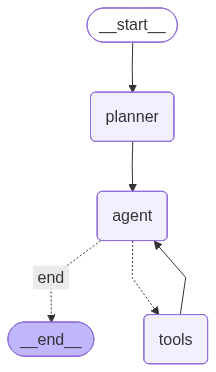

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

# **Investigation Execution**

In this section, we will run **3 investigation scenarios**. Each scenario uses the same pattern:

1. **Scenario Definition** - the incident question
2. **Agent Investigation** - the streamed plan, tool calls, and observations
3. **Final Report** - the agent's synthesized answer

## Utility Functions

We define utility functions to standardize common operations across our scenarios. By extracting these into reusable helpers, we keep our core logic clean and make it easier to compare the outputs of different investigations.

Here is what these two functions handle:

- `run_investigation`: Executes the LangGraph workflow for a specific trigger. It streams and prints the steps as they happen, allowing us to watch the agent's thought process in real-time, while applying a recursion limit to prevent infinite loops.

- `extract_incident_report`: Parses the generated message history to isolate the agent's final report and maps out a clear "evidence chain," showing exactly which tools were called and the snippets they returned.

In [ ]:
def run_investigation(trigger: str, verbose: bool = True,
                       max_steps: int = 25):
    """
    Run a complete investigation. Returns (final_output, all_messages).

    The recursion limit is set with some headroom so the agent can chain
    a handful of tool calls. If the agent exceeds it, the run is halted.
    """
    print("=" * 70)
    print("INITIATING INVESTIGATION")
    print("=" * 70)
    print(f"Trigger: {trigger}")
    print("=" * 70)

    initial_state: AgentState = {
        "messages": [HumanMessage(content=trigger)],
        "investigation_trigger": trigger,
        "plan": "",
    }

    config = {"recursion_limit": max_steps}

    final_output = None
    all_messages: list[BaseMessage] = []
    step = 0

    for output in app.stream(initial_state, config=config):
        step += 1
        final_output = output

        for node_name, node_output in output.items():
            new_msgs = node_output.get("messages", []) or []
            all_messages.extend(new_msgs)

            if verbose:
                print(f"\n{'-' * 70}")
                print(f"STEP {step}: NODE = {node_name.upper()}")
                print("-" * 70)

                if node_name == "planner" and node_output.get("plan"):
                    print("\nPLAN:")
                    print(node_output["plan"])
                    continue

                for m in new_msgs:
                    if isinstance(m, AIMessage):
                        if m.content and not m.content.startswith("[PLAN]"):
                            preview = m.content[:600]
                            print(f"\nREASONING:\n{preview}"
                                  + ("..." if len(m.content) > 600 else ""))
                        if getattr(m, "tool_calls", None):
                            print("\nTOOL CALLS:")
                            for tc in m.tool_calls:
                                args_preview = ", ".join(
                                    f"{k}={str(v)[:60]}"
                                    for k, v in tc["args"].items()
                                )
                                print(f"  - {tc['name']}({args_preview})")
                    elif isinstance(m, ToolMessage):
                        preview = m.content[:400].replace("\n", " ")
                        print(f"\nTOOL RESULT:\n{preview}"
                              + ("..." if len(m.content) > 400 else ""))

    print(f"\n{'=' * 70}")
    print(f"Investigation complete in {step} streamed steps.")
    print("=" * 70)
    return final_output, all_messages

In [ ]:
def extract_incident_report(all_messages):
    """Pretty-print the final report and the evidence chain."""
    print("\n" + "=" * 70)
    print("FINAL INVESTIGATION REPORT")
    print("=" * 70)

    # Find the last AIMessage with content and no tool calls
    final_text = None
    for m in reversed(all_messages):
        if (isinstance(m, AIMessage)
                and m.content
                and not getattr(m, "tool_calls", None)
                and not m.content.startswith("[PLAN]")):
            final_text = m.content
            break

    if final_text:
        print(final_text)
    else:
        print("(no final report produced)")

    # Evidence chain
    print("\n" + "-" * 70)
    print("EVIDENCE CHAIN (Tool Calls)")
    print("-" * 70)

    # Map all ToolMessages by tool_call_id for precise correlation
    tool_msg_map = {}
    for m in all_messages:
        if isinstance(m, ToolMessage):
            tool_msg_map[m.tool_call_id] = m

    tool_calls_seen = 0
    for m in all_messages:
        if isinstance(m, AIMessage) and getattr(m, "tool_calls", None):
            for tc in m.tool_calls:
                tool_calls_seen += 1
                args_str = ", ".join(
                    f"{k}={str(v)[:50]}" for k, v in tc["args"].items()
                )
                print(f"\n{tool_calls_seen}. {tc['name']}({args_str})")

                # Fetch the corresponding tool execution output via tool_call_id
                tc_id = tc.get("id")
                if tc_id and tc_id in tool_msg_map:
                    follow = tool_msg_map[tc_id]
                    snippet = follow.content[:200].replace("\n", " ")
                    print(f"    -> {snippet}"
                          + ("..." if len(follow.content) > 200 else ""))
                else:
                    print("    -> (No matching tool result found)")

    print(f"\n{'=' * 70}")
    print(f"Total tool calls: {tool_calls_seen}")
    print("=" * 70)

## Investigation Scenario 1: Open Payment Slowness Investigation

#### Scenario Definition

**Scenario:** The on-call engineer receives an alert that the payment portal has been slow since around 06:30 on 2025-06-15. They don't know yet what's causing it. The investigation should pull relevant logs, check service dependencies, and produce a working hypothesis with supporting evidence.

- **Trigger:** payment slowness on 2025-06-15
- **What we're testing:** The agent's ability to handle an open-ended investigation. SQL exploration is the primary mode, with Python likely needed to summarize what's in the retrieved logs.
- **Expected mix of tools:** SQL (heavy), Python (some), web search (possibly, if the agent encounters an unfamiliar message in the data)

#### Agent Investigation

In [ ]:
trigger_1 = (
    "On-call alert at 06:35 on 2025-06-15: payment portal response times "
    "have been elevated since around 06:30. Multiple users have reported "
    "checkout failures. Investigate what is going on, identify the most "
    "likely root cause, and recommend next steps."
)

result_1, messages_1 = run_investigation(trigger_1, verbose=True)

INITIATING INVESTIGATION
Trigger: On-call alert at 06:35 on 2025-06-15: payment portal response times have been elevated since around 06:30. Multiple users have reported checkout failures. Investigate what is going on, identify the most likely root cause, and recommend next steps.

----------------------------------------------------------------------
STEP 1: NODE = PLANNER
----------------------------------------------------------------------

PLAN:
1. **query_logs**: Retrieve raw records from `server_logs` for the payment portal service. Use filters for `service_name` as "payment_portal", `timeframe` from '2025-06-15 06:30:00' to '2025-06-15 06:40:00', and `log_level` to capture all logs. This will help identify any anomalies or errors occurring during the reported timeframe.

2. **run_python_analysis**: Analyze the retrieved log data to calculate the average and maximum `response_time_ms` for the payment portal service. Check for any instances where `response_time_ms` exceeds the cr

#### Final Report

In [ ]:
extract_incident_report(messages_1)


FINAL INVESTIGATION REPORT
### Summary of Findings
The payment portal has been experiencing elevated response times and checkout failures since 06:30 on 2025-06-15. Logs indicate a critical issue with the `payment-api` service, specifically a "Connection refused" error when attempting to reach the `payment-gateway`. This has led to a retry storm and high resource usage on `server_02`.

### Root Cause Hypothesis
**High Confidence**: The root cause is likely a connectivity issue between the `payment-api` and the `payment-gateway`, as indicated by the "Connection refused" error. This has caused a backlog of requests and high CPU and memory usage on the server.

### Evidence Chain
1. **Query Logs**: Retrieved logs from `payment-api` showing elevated response times, retry storms, and a critical "Connection refused" error.
2. **Service Dependencies**: Confirmed `payment-api` depends on `payment-gateway` for processing payments.
3. **Known Patterns**: Identified "Connection refused" as a kno

#### Observations

- Successfully narrowed the investigation to the reported incident window and retrieved warning, error, and critical telemetry from `payment-api`, allowing rapid identification of the failure sequence.

- Found direct evidence linking the customer-facing symptoms to backend infrastructure issues, including checkout timeout events and a critical `"Connection refused"` error involving the downstream `payment-gateway`.

- Used service dependency data to validate that `payment-gateway` is a critical dependency of `payment-api`, strengthening the root-cause hypothesis and ruling out a purely application-level failure.

- Cross-referenced observed errors against known operational failure patterns to increase confidence in the diagnosis without requiring broader exploratory searches.

- Produced a focused incident report that connected user impact, probable root cause, affected services, and remediation steps, reducing the amount of manual triage required from the on-call engineer.

## Investigation Scenario 2: Unfamiliar Error Signature in Reports Service

#### Scenario Definition

**Scenario:** The reporting service started failing intermittently in the morning. The error message is unfamiliar, not in the team's runbook. The engineer wants to know what the error means, whether it's a known issue with the upstream service, and how to mitigate it.

- **Trigger:** unfamiliar S3 error on reporting-service
- **What we're testing:** The agent should consult `get_known_patterns`, find no match, and reach for `web_search`. The web search result should inform the diagnosis.
- **Expected mix of tools:** SQL (light), web search (essential), Python (optional)

#### Agent Investigation

In [ ]:
trigger_2 = (
    "The reporting-service on server_03 logged a CRITICAL error around "
    "08:45 on 2025-06-15 that the team hasn't seen before - something "
    "about 'SlowDown 503'. Pull the relevant log entries, work out what "
    "the error actually means, whether it indicates an issue on our side "
    "or on the upstream provider's side, and recommend mitigation steps."
)

result_2, messages_2 = run_investigation(trigger_2, verbose=True)

INITIATING INVESTIGATION
Trigger: The reporting-service on server_03 logged a CRITICAL error around 08:45 on 2025-06-15 that the team hasn't seen before - something about 'SlowDown 503'. Pull the relevant log entries, work out what the error actually means, whether it indicates an issue on our side or on the upstream provider's side, and recommend mitigation steps.

----------------------------------------------------------------------
STEP 1: NODE = PLANNER
----------------------------------------------------------------------

PLAN:
1. **Query Logs**: Use the `query_logs` tool to retrieve all log entries for the reporting-service on server_03 with a log level of CRITICAL around the time of the incident. Set the timeframe from '2025-06-15 08:40:00' to '2025-06-15 08:50:00'. This will help us capture the specific 'SlowDown 503' error and any related logs.

2. **Get Known Patterns**: Use the `get_known_patterns` tool to check if the 'SlowDown 503' error matches any known error signature

#### Final Report

In [ ]:
extract_incident_report(messages_2)


FINAL INVESTIGATION REPORT
### Summary of Findings
The `reporting-service` on `server_03` encountered a CRITICAL error at 08:45 on 2025-06-15, related to an S3 client error: "SlowDown (503) - Please reduce your request rate." This error indicates that the request rate to Amazon S3 was too high, causing S3 to throttle the requests. This is a known issue with S3 when the request rate exceeds the allowed limits.

### Root Cause Hypothesis
**Confidence: High**  
The root cause of the error is the high request rate to Amazon S3, which triggered the "503 Slow Down" error. This is an issue on our side, as it relates to how our application is interacting with S3, rather than a fault with the S3 service itself.

### Evidence Chain
1. **Log Retrieval**: Queried logs from `server_03` for the `reporting-service` around the time of the incident, revealing the "SlowDown (503)" error.
2. **Known Patterns Check**: Verified that this error was not in the known error patterns.
3. **Web Search**: Conduc

#### Observations

- Successfully retrieved the critical incident log from `reporting-service` and isolated the unfamiliar `"SlowDown (503)"` error that triggered the investigation.

- Verified that the error signature was not present in the internal known-pattern database, creating a legitimate need for external investigation rather than relying solely on local knowledge.

- Correctly used `web_search` to determine that `"SlowDown (503)"` is an Amazon S3 throttling response generated when request rates exceed service limits.

- Distinguished between an application defect and an upstream dependency constraint, concluding that the immediate failure originated from interactions with S3 rather than an internal reporting-service bug.

- Combined evidence from local telemetry and external documentation to build a high-confidence root-cause hypothesis and explain the operational meaning of an otherwise unfamiliar error message.

- Produced actionable mitigation guidance centered on request-rate management, retry behavior, and backoff strategies, giving engineers clear next steps for reducing the likelihood of future throttling events.

## Investigation Scenario 3: Cross-Server Performance Comparison

#### Scenario Definition



**Scenario:** Multiple teams reported intermittent latency throughout the week, but no single outage or incident explains the complaints. The engineer needs to review warning, error, and critical telemetry across services, identify which systems experienced the most degradation, determine how widespread the impact was, and form an evidence-based hypothesis about the likely causes.

- **Trigger:** Week-long fleet performance review following widespread latency complaints.
- What we're testing: The agent's ability to collect fleet-wide telemetry, perform quantitative comparisons across services and servers, identify abnormal performance patterns, and synthesize an evidence-based root-cause hypothesis with an associated blast-radius assessment.
- Expected mix of tools: SQL (essential for log gathering), Python (essential for quantitative analysis and ranking), web search (unlikely).

#### Agent Investigation

In [ ]:
trigger_3 = (
    "Something felt off across the platform last week "
    "(2025-06-09 to 2025-06-15). Latency complaints were coming from "
    "multiple teams, but nobody could identify a single outage or failing "
    "service. Pull the relevant telemetry, compare behavior across servers "
    "and services, identify what stood out from the norm acting as a data scientist"
    "and explain what the evidence suggests were the biggest contributors to the slowdown."
)
result_3, messages_3 = run_investigation(trigger_3, verbose=True)

INITIATING INVESTIGATION
Trigger: Something felt off across the platform last week (2025-06-09 to 2025-06-15). Latency complaints were coming from multiple teams, but nobody could identify a single outage or failing service. Pull the relevant telemetry, compare behavior across servers and services, identify what stood out from the norm acting as a data scientist, and explain what the evidence suggests were the biggest contributors to the slowdown.

----------------------------------------------------------------------
STEP 1: NODE = PLANNER
----------------------------------------------------------------------

PLAN:
1. **Query Logs for Latency Data**: Use the `query_logs` tool to retrieve records from `server_logs` for the timeframe '2025-06-09 00:00:00' to '2025-06-15 23:59:59'. Filter by `log_level` to include only logs with latency-related information, such as `response_time_ms`. This will help us gather all relevant latency data across all servers and services during the specified

#### Final Report

In [ ]:
extract_incident_report(messages_3)


FINAL INVESTIGATION REPORT
### Summary of Findings
During the week of June 9 to June 15, 2025, the platform experienced significant latency issues, particularly affecting the `payment-api`, `auth-service`, and `order-service`. These services showed elevated response times and resource usage, with `payment-api` having the highest average response time. Server `server_01` and `server_02` were notably impacted, showing high CPU and memory usage, which contributed to the overall slowdown.

### Root Cause Hypothesis
**Confidence Level: High**  
The root cause of the slowdown appears to be resource exhaustion and performance degradation in the `payment-api` and `auth-service`, particularly on `server_01` and `server_02`. These services experienced high response times and resource usage, leading to cascading effects on other services like `order-service`.

### Evidence Chain
1. **Log Statistics**: Aggregated log counts showed high activity in `payment-api` and `order-service`.
2. **Log Analy

#### Observations


- Identified `payment-api`, `auth-service`, and `order-service` as the primary contributors to platform degradation, with `server_01` and `server_02` showing the strongest indicators of sustained performance pressure.

- Determined that the impact extended beyond a single service, affecting multiple application components and confirming a broad operational issue rather than an isolated incident.

- Produced an evidence-based root-cause hypothesis linking elevated latency to sustained resource pressure and performance degradation observed across the most affected services and servers.

- Generated a clear blast-radius assessment and prioritized remediation recommendations, reducing the amount of manual investigation required from infrastructure engineers.

- Demonstrated successful data flow between tools by passing fleet-wide telemetry from `query_logs` directly into `run_python_analysis`, enabling automated aggregation and ranking of affected services and infrastructure components.

# **Actionable Insights and Business Recommendations**

### Actionable Insights


The agent demonstrates the key capabilities required for operational investigations:

* Investigation strategies adapt to the problem type. Scenario 1 performs incident triage and dependency analysis, Scenario 2 combines local telemetry with external research to explain an unfamiliar error, and Scenario 3 combines fleet-wide log retrieval with Python-based quantitative analysis to identify the services and servers most strongly associated with performance degradation.

* **Planning provides clear investigation direction.** The agent consistently breaks problems into structured steps focused on relevant systems, time windows, and evidence sources.

* Tools work together in a transparent workflow. Log retrieval, dependency analysis, quantitative analysis, pattern lookup, and external research are combined to support evidence-based conclusions.

* **Evidence drives conclusions.** Root-cause hypotheses are grounded in observed telemetry, dependency relationships, known error signatures, and service behavior.

* **Reports communicate findings clearly.** Each investigation produces a root-cause hypothesis, supporting evidence, blast-radius assessment, and recommended next actions.

This project intentionally keeps the architecture simple: one agent, a focused toolset, a single workflow, and three representative investigation scenarios.

### Business Recommendations


* Use the assistant as a **first-pass investigation accelerator** to reduce manual triage effort and surface likely causes faster.

* Continuously maintain the **known_error_patterns** repository to improve future diagnostic accuracy and consistency.

* Keep **service_dependencies** metadata current to strengthen dependency analysis and blast-radius assessment.

* Encourage evidence-based investigations by combining telemetry, quantitative analysis, dependency context, and external knowledge when required.

* Collect feedback on investigation quality and actionability to continuously improve performance.

<font size=6 color='blue'>Power Ahead!</font>
___